In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import glob
import json

# Parity over phi

In [2]:
# read txt file and import as dictionary

with open('Joint Measurements\\Variation in phi\\data.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


Text(0, 0.5, 'Parity')

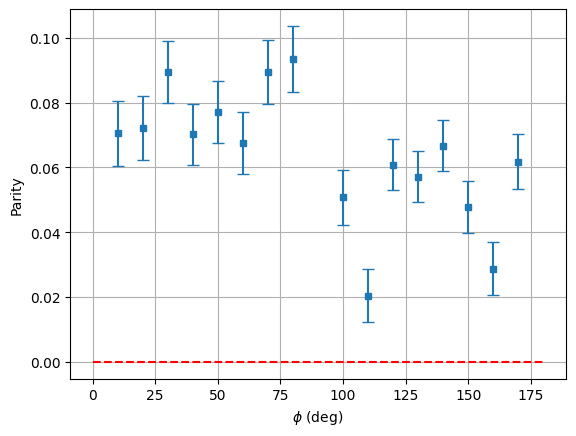

In [3]:
# calculate populations of states 00, 10, 01, 11 from dictionary values and calculate parity

keys = ["Ion 1","Ion 2"]
phases = np.delete(np.arange(10,171,10),8)
parity_phi = []
err_parity_phi = []
for i in phases: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    upup_count = 0
    downdown_count = 0
    others_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] != ion2[j]: 
            others_count += 1
        elif ion1[j] == 0: 
            downdown_count += 1
        else: 
            upup_count += 1
    parity_phi.append(upup_count/n + downdown_count/n - others_count/n)
    upup_err = np.sqrt(upup_count/n * (1.0 - upup_count/n) / n)
    downdown_err = np.sqrt(downdown_count/n * (1.0 - downdown_count/n) / n)
    others_err = np.sqrt(others_count/n * (1.0 - others_count/n) / n)
    err = np.sqrt(upup_err**2 + downdown_err**2 + others_err**2)
    err_parity_phi.append(err)

plt.errorbar(phases,parity_phi,(np.array(err_parity_phi)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.hlines(0,0,180, linestyle = '--', color = 'r')
plt.grid()
plt.xlabel(r'$\phi$ (deg)')
plt.ylabel("Parity")


# X basis measurements over phi

In [4]:
# read txt file and import as dictionary

with open('Individual Measurements\\Variation in phi\\X\\data.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


Text(0, 0.5, 'Expectation Value')

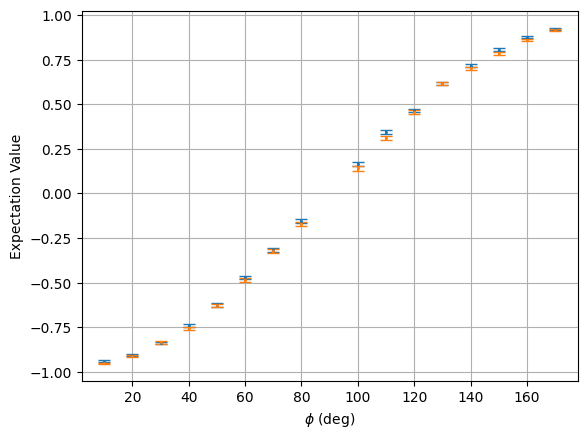

In [5]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

keys = ["Ion 1","Ion 2"]
phases = np.delete(np.arange(10,171,10),8)
X1_phi = []
err_X1_phi = []
X2_phi = []
err_X2_phi = []
for i in phases: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1
    X1_phi.append(up1_count/n)
    X2_phi.append(up2_count/n)
    err_X1_phi.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    err_X2_phi.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))

X1_phi = 2*np.array(X1_phi) - 1
err_X1_phi = 2*np.array(err_X1_phi)
X2_phi = 2*np.array(X2_phi) - 1
err_X2_phi = 2*np.array(err_X2_phi)

plt.errorbar(phases,X1_phi, err_X1_phi, linestyle = '', marker='s', capsize = 4, markersize = 1, label = "Ion 1")
plt.errorbar(phases,X2_phi, err_X2_phi, linestyle = '', marker='s', capsize = 4, markersize = 1, label = "Ion 2")
plt.grid()
plt.xlabel(r'$\phi$ (deg)')
plt.ylabel("Expectation Value")


# Y basis measurements over phi

In [6]:
# read txt file and import as dictionary

with open('Individual Measurements\\Variation in phi\\Y\\data.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


(-1.1, 1.1)

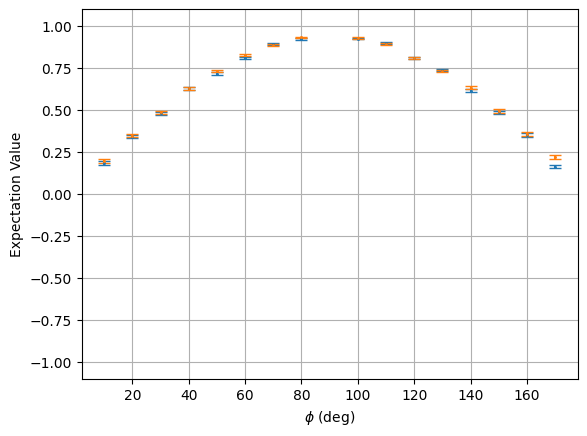

In [7]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

keys = ["Ion 1","Ion 2"]
phases = np.delete(np.arange(10,171,10),8)
Y1_phi = []
err_Y1_phi = []
Y2_phi = []
err_Y2_phi = []
for i in phases: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1
    Y1_phi.append(up1_count/n)
    Y2_phi.append(up2_count/n)
    err_Y1_phi.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    err_Y2_phi.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))

Y1_phi = 2*np.array(Y1_phi) - 1
err_Y1_phi = 2*np.array(err_Y1_phi)
Y2_phi = 2*np.array(Y2_phi) - 1
err_Y2_phi = 2*np.array(err_Y2_phi)

plt.errorbar(phases,Y1_phi, err_Y1_phi, linestyle = '', marker='s', capsize = 4, markersize = 1, label = "Ion 1")
plt.errorbar(phases,Y2_phi, err_Y2_phi, linestyle = '', marker='s', capsize = 4, markersize = 1, label = "Ion 2")
plt.grid()
plt.xlabel(r'$\phi$ (deg)')
plt.ylabel("Expectation Value")
plt.ylim([-1.1,1.1])


# Generating the paper figures

Text(0.5, 0, '$\\phi$ (deg)')

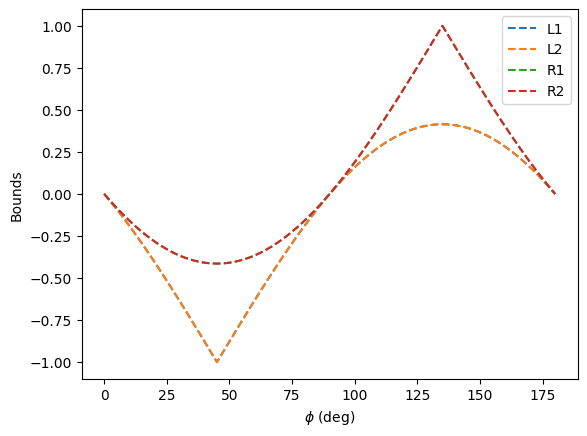

In [8]:
# generating theory/simulation lines from qutip

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from numpy import pi
import qutip as qt
#from qutip import gates as gt
import qutip_qip as qip
from qutip_qip.operations import MS
from scipy.optimize import curve_fit

qubit_g = qt.basis(2,0)
qubit_e = qt.basis(2,1)

plus  = (qt.basis(2,0) + qt.basis(2,1))/np.sqrt(2.)
minus = (qt.basis(2,0) - qt.basis(2,1))/np.sqrt(2.)

plusy = (qt.basis(2,0) + 1.0j * qt.basis(2,1))/np.sqrt(2.)
minusy = (qt.basis(2,0) - 1.0j * qt.basis(2,1))/np.sqrt(2.)

qubit_gg = qt.tensor(qubit_g,qubit_g)
qubit_ge = qt.tensor(qubit_g,qubit_e)
qubit_eg = qt.tensor(qubit_e,qubit_g)
qubit_ee = qt.tensor(qubit_e,qubit_e)

def R(theta,phi): 
    # phi = {+x,+y,-x,-y} = {0,pi/2,pi,1.5*pi}
    return qt.Qobj([[np.cos(theta/2),-np.sin(theta/2)*np.exp(-1j*phi)*1j],[-np.sin(theta/2)*np.exp(1j*phi)*1j,np.cos(theta/2)]])

R(pi/2,0)

phases = np.linspace(0,180,1000)
parity = []
gg = []
ge = []
eg = []
ee = []
geeg = []
qubit0x = []
qubit1x = []
for i in phases:
    phi = i * pi / 180
    psi = qt.tensor(R(0.50*pi,phi),R(0.50*pi,phi)) * qubit_gg #stateprep
    psi = qt.tensor(R(0.50*pi,1.00*pi),R(0.50*pi,1.00*pi)) * psi #basis transformation
    gg.append(np.real(psi.proj()[0][0]))
    ge.append(np.real(psi.proj()[1][1]))
    eg.append(np.real(psi.proj()[2][2]))
    ee.append(np.real(psi.proj()[3][3]))
    geeg.append(np.real(psi.proj()[1][1])+np.real(psi.proj()[2][2]))
    parity.append(np.real(psi.proj()[0][0])+np.real(psi.proj()[3][3])-np.real(psi.proj()[1][1])-np.real(psi.proj()[2][2]))
    qubit0x.append(np.real(psi.proj()[2][2]) + np.real(psi.proj()[3][3]))
    qubit1x.append(np.real(psi.proj()[1][1]) + np.real(psi.proj()[3][3]))

parity = []
gg = []
ge = []
eg = []
ee = []
geeg = []
qubit0y = []
qubit1y = []
for i in phases:
    phi = i * pi / 180
    psi = qt.tensor(R(0.50*pi,phi),R(0.50*pi,phi)) * qubit_gg #stateprep
    psi = qt.tensor(R(0.50*pi,0.5*pi),R(0.50*pi,0.50*pi)) * psi #basis transformation
    gg.append(np.real(psi.proj()[0][0]))
    ge.append(np.real(psi.proj()[1][1]))
    eg.append(np.real(psi.proj()[2][2]))
    ee.append(np.real(psi.proj()[3][3]))
    geeg.append(np.real(psi.proj()[1][1])+np.real(psi.proj()[2][2]))
    parity.append(np.real(psi.proj()[0][0])+np.real(psi.proj()[3][3])-np.real(psi.proj()[1][1])-np.real(psi.proj()[2][2]))
    qubit0y.append(np.real(psi.proj()[2][2]) + np.real(psi.proj()[3][3]))
    qubit1y.append(np.real(psi.proj()[1][1]) + np.real(psi.proj()[3][3]))

exp0x_avg = 2*np.array(qubit0x) - 1
exp1x_avg = 2*np.array(qubit1x) - 1
exp0y_avg = 2*np.array(qubit0y) - 1
exp1y_avg = 2*np.array(qubit1y) - 1

more_phases = phases

L1_thry = np.abs(exp0x_avg + exp0y_avg) - 1 
L2_thry = np.abs(exp1x_avg + exp1y_avg) - 1 
R1_thry = 1 - np.abs(exp0x_avg - exp0y_avg)
R2_thry = 1 - np.abs(exp1x_avg - exp1y_avg) 

plt.plot(more_phases, L1_thry, '--', label="L1")
plt.plot(more_phases, L2_thry, '--', label="L2")
plt.plot(more_phases, R1_thry, '--', label="R1")
plt.plot(more_phases, R2_thry, '--', label="R2")
plt.legend()
plt.ylabel("Bounds")
plt.xlabel(r'$\phi$ (deg)')

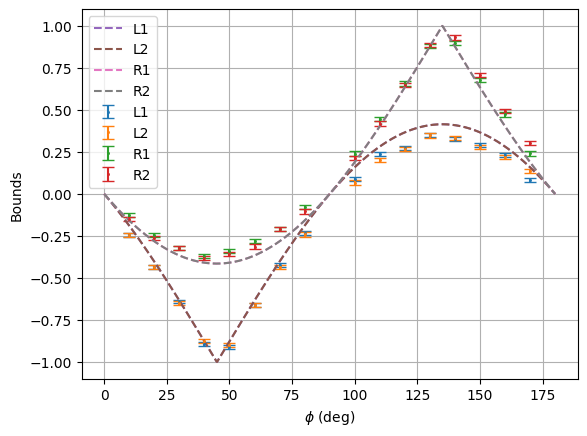

In [9]:
# calculate bounds from averages and errors on the bounds

phases = np.delete(np.arange(10,171,10),8)

L1 = np.abs(np.array(X1_phi) + np.array(Y1_phi)) - 1
L2 = np.abs(np.array(X2_phi) + np.array(Y2_phi)) - 1
R1 = 1 - np.abs((np.array(X1_phi) - np.array(Y1_phi)))
R2 = 1 - np.abs((np.array(X2_phi) - np.array(Y2_phi)))

L1_err = np.sqrt(np.array(err_X1_phi)**2 + np.array(err_Y1_phi)**2)
L2_err = np.sqrt(np.array(err_X2_phi)**2 + np.array(err_Y2_phi)**2)
R1_err = np.sqrt(np.array(err_X1_phi)**2 + np.array(err_Y1_phi)**2)
R2_err = np.sqrt(np.array(err_X2_phi)**2 + np.array(err_Y2_phi)**2)

plt.errorbar(phases,L1, L1_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="L1")
plt.errorbar(phases,L2, L2_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="L2")
plt.errorbar(phases,R1, R1_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="R1")
plt.errorbar(phases,R2, R2_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="R2")
plt.legend(loc="upper left")

plt.plot(more_phases, L1_thry, '--', label="L1")
plt.plot(more_phases, L2_thry, '--', label="L2")
plt.plot(more_phases, R1_thry, '--', label="R1")
plt.plot(more_phases, R2_thry, '--', label="R2")

plt.ylabel("Bounds")
plt.xlabel(r'$\phi$ (deg)')
plt.legend()
plt.grid()

# theory lines not included

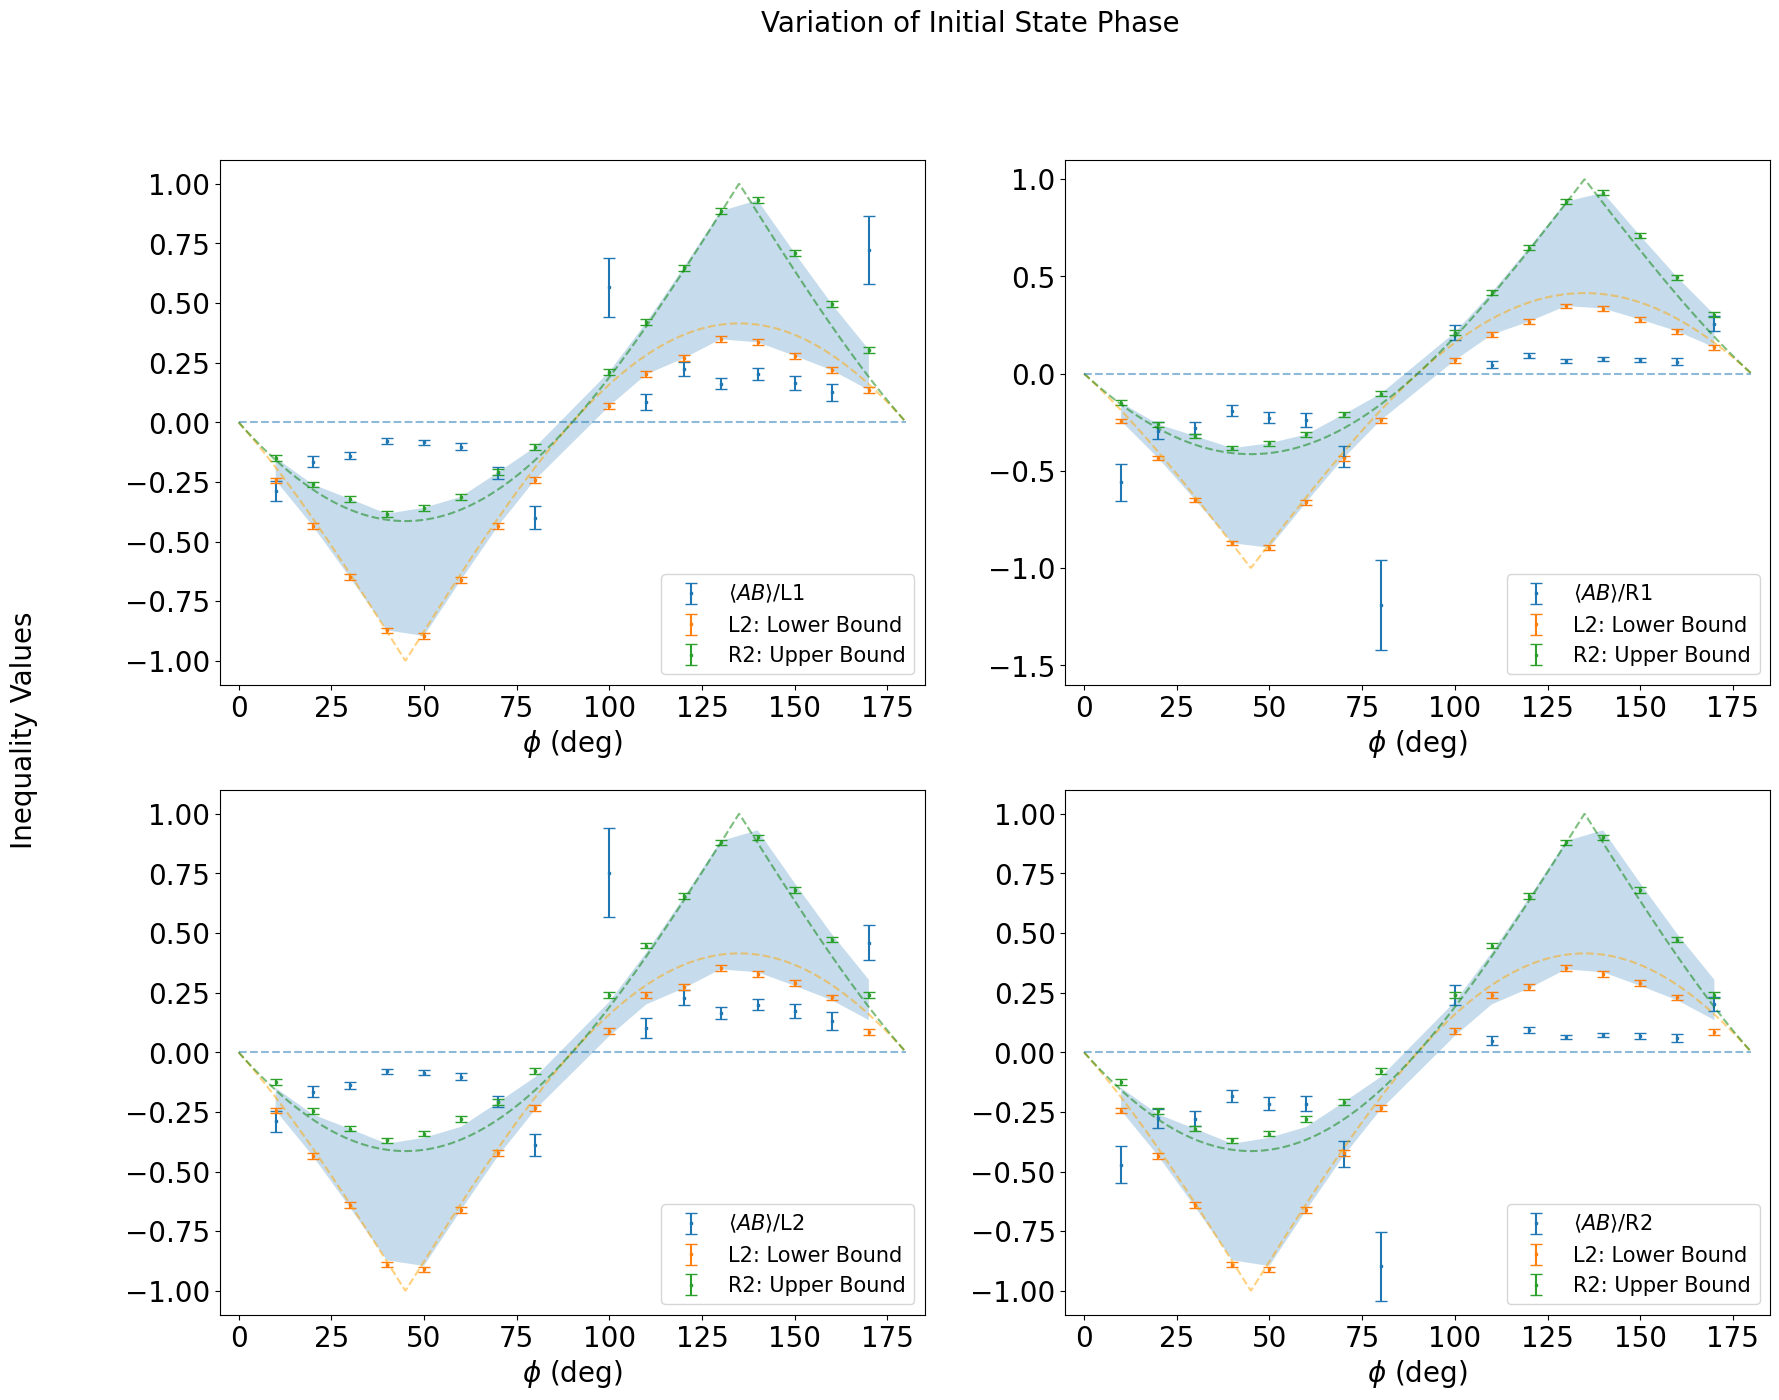

In [10]:
# generating the paper figures

fig, ax = plt.subplots(2, 2, figsize = (20, 15))
fig.suptitle('Variation of Initial State Phase', fontsize=20)
fig.supylabel('Inequality Values', fontsize=20)

bounds = [[L1,L1_err,L2,L2_err,R2,R2_err,'L1'], [R1,R1_err,L2,L2_err,R2,R2_err,'R1'], [L2,L2_err,L1,L1_err,R1,R1_err,'L2'], [R2,R2_err,L1,L1_err,R1,R1_err,'R2']]

for nn, ax in enumerate(ax.flat):
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    ineq = np.array(parity_phi) / np.array(bounds[nn][0])
    ineq_err = np.abs(np.array(ineq)) * np.sqrt((np.array(err_parity_phi) / np.array(parity_phi))**2 + (np.array(bounds[nn][1]) / np.array(bounds[nn][0]))**2)
    ax.errorbar(phases,ineq, ineq_err, linestyle = '', marker='s', capsize = 4, markersize = 2, label= r'$\left\langle AB \right\rangle$/' + bounds[nn][6])
    ax.errorbar(phases,bounds[nn][2], bounds[nn][3], linestyle = '', marker='s', capsize = 4, markersize = 2, label="L2: Lower Bound")
    ax.errorbar(phases,bounds[nn][4], bounds[nn][5], linestyle = '', marker='s', capsize = 4, markersize = 2, label="R2: Upper Bound")
    if nn in [2,3]: 
        ax.plot(more_phases, L1_thry, '--', color = 'orange', alpha=0.5)
        ax.plot(more_phases, R1_thry, '--', color = 'green', alpha=0.5)
    if nn in [0,1]: 
        ax.plot(more_phases, L2_thry, '--', color = 'orange', alpha=0.5)
        ax.plot(more_phases, R2_thry, '--', color = 'green', alpha=0.5)
    ax.hlines(0,0,180,linestyle = '--', alpha = 0.5)
    ax.legend(loc="lower right", prop={'size': 15})
    ax.set_ylim([-1.1,1.1])
    if nn == 1: 
        ax.set_ylim([-1.6,1.1])
    ax.set_xlim([-5, 185])
    ax.fill_between(phases,L2,R2, alpha=0.25)
    ax.set_xlabel(r'$\phi$ (deg)', fontsize=20)

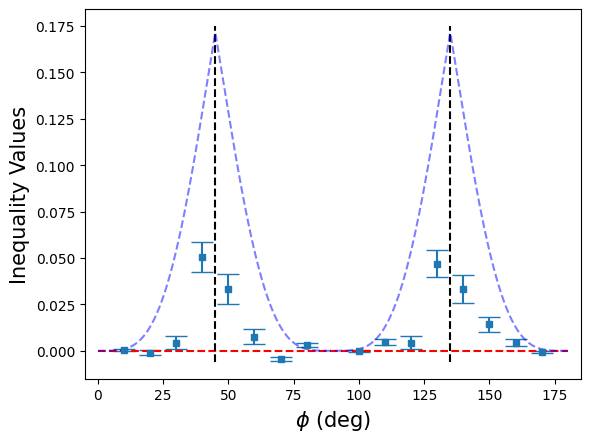

In [11]:
# generating the paper figures

AB = parity_phi
AB_err = err_parity_phi

bound_products = [L1*L2,L1*R2,R1*L2,R1*R2]
bound_products_err = []
bound_products_err.append(np.abs(L1*L2)*np.sqrt(((L2_err) / (L2))**2 + ((L1_err) / (L1))**2))
bound_products_err.append(np.abs(L1*R2)*np.sqrt(((R2_err) / (R2))**2 + ((L1_err) / (L1))**2))
bound_products_err.append(np.abs(R1*L2)*np.sqrt(((L2_err) / (L2))**2 + ((R1_err) / (R1))**2))
bound_products_err.append(np.abs(R1*R2)*np.sqrt(((R2_err) / (R2))**2 + ((R1_err) / (R1))**2))

min_idx = 0
max_idx = 0

x = phases
y = []
z = []


for i in range(len(AB)): 
    bound_products_invd = [bound_products[0][i], bound_products[1][i], bound_products[2][i], bound_products[3][i]]
    bound_products_invd_err = [bound_products_err[0][i], bound_products_err[1][i], bound_products_err[2][i], bound_products_err[3][i]]
    min_idx = bound_products_invd.index(min(bound_products_invd))
    max_idx = bound_products_invd.index(max(bound_products_invd))
    AB_max = AB[i] - bound_products_invd[max_idx]
    AB_min = AB[i] - bound_products_invd[min_idx]
    y.append(AB_max*AB_min)
    
    AB_max_err = np.sqrt(AB_err[i]**2 + bound_products_invd_err[max_idx]**2)
    AB_min_err = np.sqrt(AB_err[i]**2 + bound_products_invd_err[min_idx]**2)
    
    overall_err = np.abs(AB_max*AB_min)*np.sqrt(((AB_max_err) / (AB_max))**2 + ((AB_min_err) / (AB_min))**2)
    z.append(overall_err)

plt.errorbar(x,y,z, linestyle = '', marker='s', capsize = 8, markersize = 5, label= '')
plt.xlabel(r'$\phi$ (deg)', fontsize=15)
plt.ylabel('Inequality Values', fontsize=15)
plt.tick_params(axis='both', labelsize = 10)
plt.xlim([-5, 185])
plt.hlines(0,0,180,linestyle = '--',color = 'r')
plt.vlines(45,-0.006, 0.175,linestyle = '--',color = 'k')
plt.vlines(135,-0.006, 0.175,linestyle = '--',color = 'k')

eqn_41 = []

for i in range(len(L1_thry)): 
    max_bounds = max([L1_thry[i]*L2_thry[i],L1_thry[i]*R2_thry[i],R1_thry[i]*L2_thry[i],R1_thry[i]*R2_thry[i]])
    min_bounds = min([L1_thry[i]*L2_thry[i],L1_thry[i]*R2_thry[i],R1_thry[i]*L2_thry[i],R1_thry[i]*R2_thry[i]])
    eqn_41.append((0.0 - max_bounds)*(0.0 - min_bounds))

plt.plot(more_phases, eqn_41, '--', color = 'blue', alpha=0.5)


# Parity over theta

In [12]:
# read txt file and import as dictionary
# this file is specifically for theta = 0

with open('Joint Measurements\\Variation in theta\\0 theta.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


Text(0, 0.5, 'Parity')

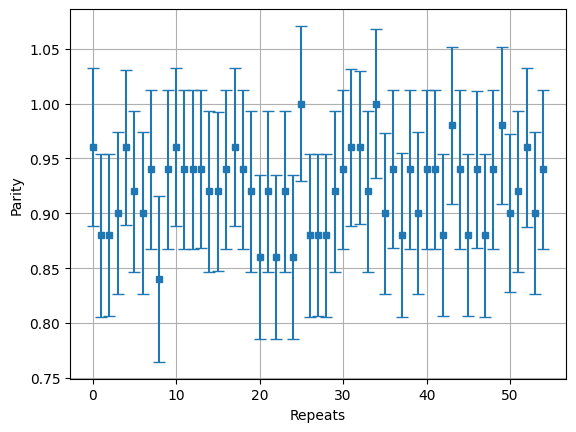

In [13]:
# calculate populations of states 00, 10, 01, 11 from dictionary values and calculate parity

keys = ["Ion 1","Ion 2"]
repeats = np.arange(0,55,1)
parity_theta = []
err_parity_theta = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    upup_count = 0
    downdown_count = 0
    others_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] != ion2[j]: 
            others_count += 1
        elif ion1[j] == 0: 
            downdown_count += 1
        else: 
            upup_count += 1
    parity_theta.append(upup_count/n + downdown_count/n - others_count/n)
    upup_err = np.sqrt(upup_count/n * (1.0 - upup_count/n) / n)
    downdown_err = np.sqrt(downdown_count/n * (1.0 - downdown_count/n) / n)
    others_err = np.sqrt(others_count/n * (1.0 - others_count/n) / n)
    err = np.sqrt(upup_err**2 + downdown_err**2 + others_err**2)
    err_parity_theta.append(err)

plt.errorbar(repeats,parity_theta,(np.array(err_parity_theta)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Parity")


number of files = 59


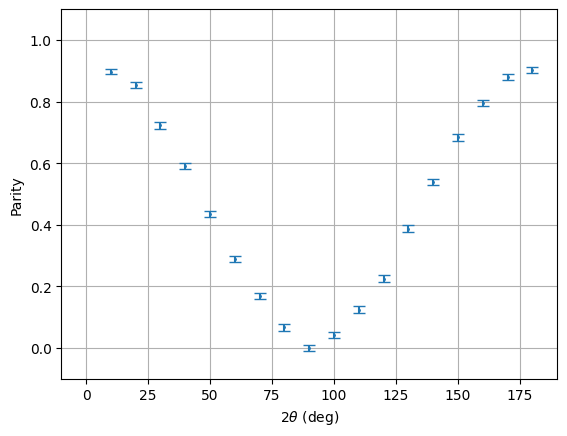

total points = 6700


In [14]:
# read populations of states 00, 10, 01, 11 from all "delay_parity" files and calculate parity

path = "Joint Measurements\\Variation in theta\\*"
path2 = "Joint Measurements\\Variation in theta\\extra\\*"

file_count = 0
total_nexp = 0

for file in glob.glob(path):
    if 'parity' in str(file):
        file_count += 1
        
for file in glob.glob(path2):
    if 'parity' in str(file):
        file_count += 1

print("number of files = " + str(file_count))

compiled_parity = []
compiled_error = []

for file in glob.glob(path):
    if 'parity' in str(file):
        j += 1
        with open(file, 'r') as file:
            file_data = []
            for line in file:
                arr = json.loads(line.strip())
                file_data.append(arr)
        #ax[j].errorbar(file_data[0],file_data[1],file_data[2], linestyle = '', marker='s', capsize = 4, markersize = 1)
        total_nexp += file_data[3]
        compiled_parity.append(np.array(file_data[1]))
        compiled_error.append(np.array(file_data[2]))
        
for file in glob.glob(path2):
    if 'parity' in str(file):
        j += 1
        with open(file, 'r') as file:
            file_data = []
            for line in file:
                arr = json.loads(line.strip())
                file_data.append(arr)
        #ax[j].errorbar(file_data[0],file_data[1],file_data[2], linestyle = '', marker='s', capsize = 4, markersize = 1)
        total_nexp += file_data[3]
        compiled_parity.append(np.array(file_data[1]))
        compiled_error.append(np.array(file_data[2]))

avg_par = []
avg_err = []
j = 0

for i in compiled_parity: 
    if j == 0: 
        avg_par = i
    else: 
        avg_par += i
    j += 1
        
avg_par = avg_par/(file_count)
j = 0

for i in compiled_error: 
    if j == 0: 
        avg_err = i**2
    else: 
        avg_err += i**2
    j += 1

avg_err = np.sqrt(avg_err)
avg_err = avg_err/(file_count)

theta = np.arange(10,181,10)

plt.errorbar(theta,avg_par, avg_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Parity")
plt.grid(True)
plt.ylim([-0.1,1.1])
plt.xlim([-10,190])
plt.ylabel("Parity")
plt.xlabel(r"2$\theta$ (deg)")
plt.show()
        
print("total points = "+str(total_nexp))

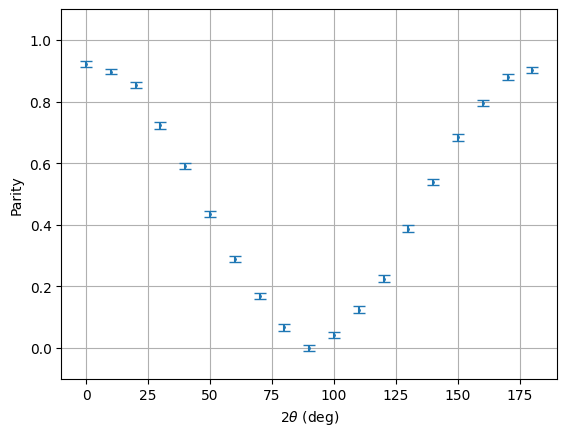

In [15]:
# patch in the parity from theta = 0

avg_par_0 = np.average(parity_theta)
avg_err_0 = 0

for i in err_parity_theta: 
    avg_err_0 += i**2

avg_err_0 = np.sqrt(avg_err_0)/len(err_parity_theta)

theta = np.insert(theta,0,0)
avg_par = np.insert(avg_par,0,avg_par_0)
avg_err = np.insert(avg_err,0,avg_err_0)

plt.errorbar(theta,avg_par, avg_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Parity")
plt.grid(True)
plt.ylim([-0.1,1.1])
plt.xlim([-10,190])
plt.ylabel("Parity")
plt.xlabel(r"2$\theta$ (deg)")
plt.show()

# X basis measurements over theta

In [16]:
# read txt file and import as dictionary
# this file is specifically for theta = 0

with open('Individual Measurements\\Variation in theta\\X\\0 theta.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


(-1.1, 1.1)

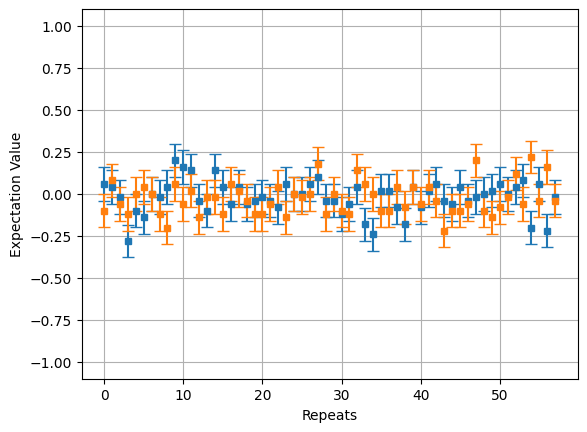

In [17]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

keys = ["Ion 1","Ion 2"]
repeats = np.arange(0,58,1)
avg_ion1x_0 = []
avg_ion1x_err_0 = []
avg_ion2x_0 = []
avg_ion2x_err_0 = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1
    avg_ion1x_0.append(up1_count/n)
    avg_ion2x_0.append(up2_count/n)
    avg_ion1x_err_0.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    avg_ion2x_err_0.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))
    
avg_ion1x_0 = 2*np.array(avg_ion1x_0) - 1
avg_ion1x_err_0 = 2*np.array(avg_ion1x_err_0)
avg_ion2x_0 = 2*np.array(avg_ion2x_0) - 1
avg_ion2x_err_0 = 2*np.array(avg_ion2x_err_0)

plt.errorbar(repeats,avg_ion1x_0,(np.array(avg_ion1x_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.errorbar(repeats,avg_ion2x_0,(np.array(avg_ion2x_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Expectation Value")
plt.ylim([-1.1,1.1])


number of files = 60
total points = 6000


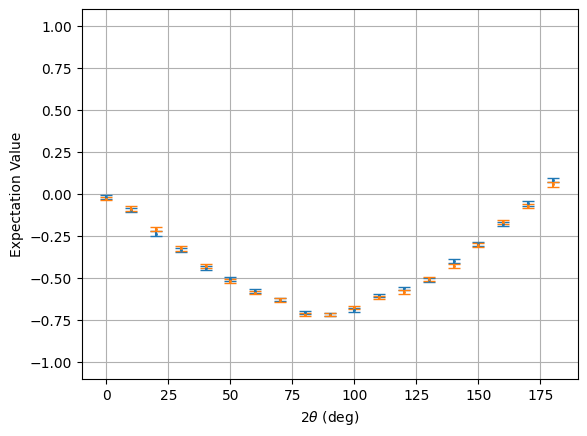

In [18]:
# read excited state populations for each ion from all "delay_single" files and calculate expectation values

path = "Individual Measurements\\Variation in theta\\X\\*"

file_count = 0
total_nexp = 0

for file in glob.glob(path):
    if 'single' in str(file):
        file_count += 1

print("number of files = " + str(file_count))

compiled_ion1x = []
compiled_ion1x_err = []
compiled_ion2x = []
compiled_ion2x_err = []

for file in glob.glob(path):
    if 'single' in str(file):
        j += 1
        with open(file, 'r') as file:
            file_data = []
            for line in file:
                arr = json.loads(line.strip())
                file_data.append(arr)
        total_nexp += file_data[5]
        compiled_ion1x.append(np.array(file_data[1]))
        compiled_ion1x_err.append(np.array(file_data[2]))
        compiled_ion2x.append(np.array(file_data[3]))
        compiled_ion2x_err.append(np.array(file_data[4]))

#########################################        

avg_ion1x = []
avg_ion1x_err = []
j = 0

for i in compiled_ion1x: 
    if j == 0: 
        avg_ion1x = i
    else: 
        avg_ion1x += i
    j += 1
        
avg_ion1x = avg_ion1x/(file_count)
j = 0

for i in compiled_ion1x_err: 
    if j == 0: 
        avg_ion1x_err = i**2
    else: 
        avg_ion1x_err += i**2
    j += 1

avg_ion1x_err = np.sqrt(avg_ion1x_err)
avg_ion1x_err = avg_ion1x_err/(file_count)

###########################################

avg_ion2x = []
avg_ion2x_err = []
j = 0

for i in compiled_ion2x: 
    if j == 0: 
        avg_ion2x = i
    else: 
        avg_ion2x += i
    j += 1
        
avg_ion2x = avg_ion2x/(file_count)
j = 0

for i in compiled_ion2x_err: 
    if j == 0: 
        avg_ion2x_err = i**2
    else: 
        avg_ion2x_err += i**2
    j += 1

avg_ion2x_err = np.sqrt(avg_ion2x_err)
avg_ion2x_err = avg_ion2x_err/(file_count)

theta = np.arange(10,181,10)

avg_exp1x = 2 * (avg_ion1x) - 1
avg_exp1x_err = 2 * avg_ion1x_err
avg_exp2x = 2 * (avg_ion2x) - 1
avg_exp2x_err = 2 * avg_ion2x_err

theta = np.insert(theta,0,0)
avg_exp1x = np.insert(avg_exp1x,0,np.average(avg_ion1x_0))
avg_exp1x_err = np.insert(avg_exp1x_err,0,np.sum(np.array(avg_ion1x_err_0)**2)/len(avg_ion1x_err_0))
avg_exp2x = np.insert(avg_exp2x,0,np.average(avg_ion2x_0))
avg_exp2x_err = np.insert(avg_exp2x_err,0,np.sum(np.array(avg_ion2x_err_0)**2)/len(avg_ion2x_err_0))

plt.errorbar(theta,avg_exp1x, avg_exp1x_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Ion 1")
plt.errorbar(theta,avg_exp2x, avg_exp2x_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Ion 2")
plt.grid(True)
plt.ylim([-1.1,1.1])
plt.xlim([-10,190])
plt.ylabel("Expectation Value")
plt.xlabel(r"2$\theta$ (deg)")
        
print("total points = "+str(total_nexp))

# Y basis measurements over theta

In [19]:
# read txt file and import as dictionary
# this file is specifically for theta = 0

with open('Individual Measurements\\Variation in theta\\Y\\0 theta.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)


(-1.1, 1.1)

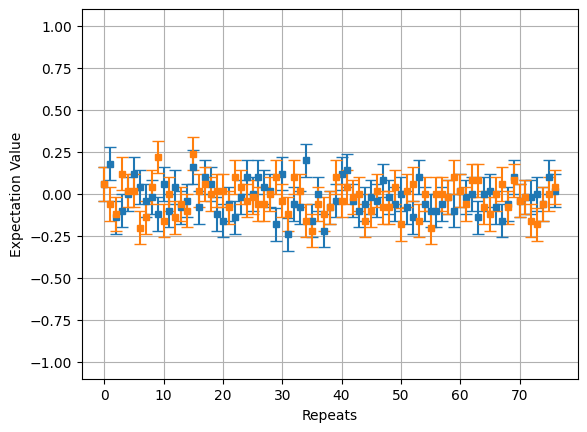

In [20]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

keys = ["Ion 1","Ion 2"]
repeats = np.arange(0,77,1)
avg_ion1y_0 = []
avg_ion1y_err_0 = []
avg_ion2y_0 = []
avg_ion2y_err_0 = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1
    avg_ion1y_0.append(up1_count/n)
    avg_ion2y_0.append(up2_count/n)
    avg_ion1y_err_0.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    avg_ion2y_err_0.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))
    
avg_ion1y_0 = 2*np.array(avg_ion1y_0) - 1
avg_ion1y_err_0 = 2*np.array(avg_ion1y_err_0)
avg_ion2y_0 = 2*np.array(avg_ion2y_0) - 1
avg_ion2y_err_0 = 2*np.array(avg_ion2y_err_0)

plt.errorbar(repeats,avg_ion1y_0,(np.array(avg_ion1y_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.errorbar(repeats,avg_ion2y_0,(np.array(avg_ion2y_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Expectation Value")
plt.ylim([-1.1,1.1])


number of files = 57
total points = 5700


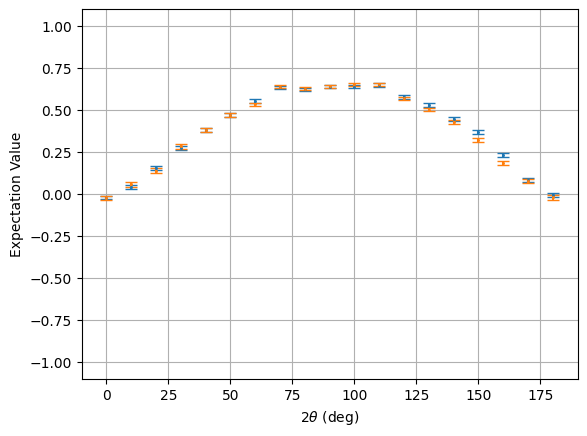

In [21]:
# read excited state populations for each ion from all "delay_single" files and calculate expectation values

path = "Individual Measurements\\Variation in theta\\Y\\*"

file_count = 0
total_nexp = 0

for file in glob.glob(path):
    if 'single' in str(file):
        file_count += 1

print("number of files = " + str(file_count))

compiled_ion1y = []
compiled_ion1y_err = []
compiled_ion2y = []
compiled_ion2y_err = []

for file in glob.glob(path):
    if 'single' in str(file):
        j += 1
        with open(file, 'r') as file:
            file_data = []
            for line in file:
                arr = json.loads(line.strip())
                file_data.append(arr)
        total_nexp += file_data[5]
        compiled_ion1y.append(np.array(file_data[1]))
        compiled_ion1y_err.append(np.array(file_data[2]))
        compiled_ion2y.append(np.array(file_data[3]))
        compiled_ion2y_err.append(np.array(file_data[4]))

#########################################        

avg_ion1y = []
avg_ion1y_err = []
j = 0

for i in compiled_ion1y: 
    if j == 0: 
        avg_ion1y = i
    else: 
        avg_ion1y += i
    j += 1
        
avg_ion1y = avg_ion1y/(file_count)
j = 0

for i in compiled_ion1y_err: 
    if j == 0: 
        avg_ion1y_err = i**2
    else: 
        avg_ion1y_err += i**2
    j += 1

avg_ion1y_err = np.sqrt(avg_ion1y_err)
avg_ion1y_err = avg_ion1y_err/(file_count)

###########################################

avg_ion2y = []
avg_ion2y_err = []
j = 0

for i in compiled_ion2y: 
    if j == 0: 
        avg_ion2y = i
    else: 
        avg_ion2y += i
    j += 1
        
avg_ion2y = avg_ion2y/(file_count)
j = 0

for i in compiled_ion2y_err: 
    if j == 0: 
        avg_ion2y_err = i**2
    else: 
        avg_ion2y_err += i**2
    j += 1

avg_ion2y_err = np.sqrt(avg_ion2y_err)
avg_ion2y_err = avg_ion2y_err/(file_count)

theta = np.arange(10,181,10)

avg_exp1y = 2 * (avg_ion1y) - 1
avg_exp1y_err = 2 * avg_ion1y_err
avg_exp2y = 2 * (avg_ion2y) - 1
avg_exp2y_err = 2 * avg_ion2y_err

theta = np.insert(theta,0,0)
avg_exp1y = np.insert(avg_exp1y,0,np.average(avg_ion1y_0))
avg_exp1y_err = np.insert(avg_exp1y_err,0,np.sum(np.array(avg_ion1y_err_0)**2)/len(avg_ion1y_err_0))
avg_exp2y = np.insert(avg_exp2y,0,np.average(avg_ion2y_0))
avg_exp2y_err = np.insert(avg_exp2y_err,0,np.sum(np.array(avg_ion2y_err_0)**2)/len(avg_ion2y_err_0))

plt.errorbar(theta,avg_exp1y, avg_exp1y_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Ion 1")
plt.errorbar(theta,avg_exp2y, avg_exp2y_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="Ion 2")
plt.grid(True)
plt.ylim([-1.1,1.1])
plt.xlim([-10,190])
plt.ylabel("Expectation Value")
plt.xlabel(r"2$\theta$ (deg)")
        
print("total points = "+str(total_nexp))

# Generating the paper figures

Text(0, 0.5, 'Bounds')

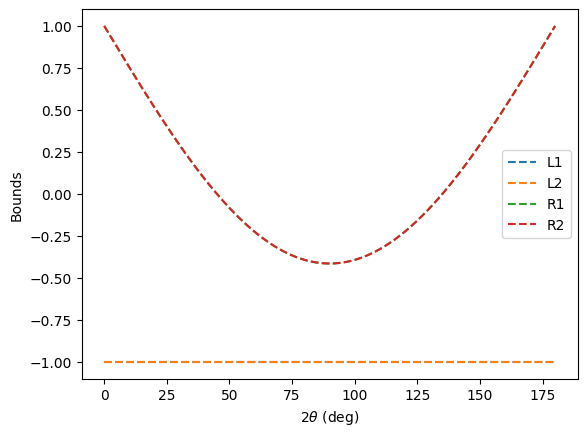

In [22]:
# generating theory lines

delays = np.linspace(0,180,1000)
parity = []
gg = []
ge = []
eg = []
ee = []
geeg = []
qubit0x = []
qubit1x = []
for i in delays:
    phi = i * pi / 180
    psi = qt.tensor(R(phi,0.75*pi),R(phi,0.75*pi)) * qubit_gg #stateprep
    psi = qt.tensor(R(0.50*pi,0.00*pi),R(0.50*pi,0.00*pi)) * psi #basis transformation
    gg.append(np.real(psi.proj()[0][0]))
    ge.append(np.real(psi.proj()[1][1]))
    eg.append(np.real(psi.proj()[2][2]))
    ee.append(np.real(psi.proj()[3][3]))
    geeg.append(np.real(psi.proj()[1][1])+np.real(psi.proj()[2][2]))
    parity.append(np.real(psi.proj()[0][0])+np.real(psi.proj()[3][3])-np.real(psi.proj()[1][1])-np.real(psi.proj()[2][2]))
    qubit0x.append(np.real(psi.proj()[2][2]) + np.real(psi.proj()[3][3]))
    qubit1x.append(np.real(psi.proj()[1][1]) + np.real(psi.proj()[3][3]))

parity = []
gg = []
ge = []
eg = []
ee = []
geeg = []
qubit0y = []
qubit1y = []
for i in delays:
    phi = i * pi / 180
    psi = qt.tensor(R(phi,0.75*pi),R(phi,0.75*pi)) * qubit_gg #stateprep
    psi = qt.tensor(R(0.50*pi,0.50*pi),R(0.50*pi,0.50*pi)) * psi #basis transformation
    gg.append(np.real(psi.proj()[0][0]))
    ge.append(np.real(psi.proj()[1][1]))
    eg.append(np.real(psi.proj()[2][2]))
    ee.append(np.real(psi.proj()[3][3]))
    geeg.append(np.real(psi.proj()[1][1])+np.real(psi.proj()[2][2]))
    parity.append(np.real(psi.proj()[0][0])+np.real(psi.proj()[3][3])-np.real(psi.proj()[1][1])-np.real(psi.proj()[2][2]))
    qubit0y.append(np.real(psi.proj()[2][2]) + np.real(psi.proj()[3][3]))
    qubit1y.append(np.real(psi.proj()[1][1]) + np.real(psi.proj()[3][3]))

qubit0x = (np.array(qubit0x)-0.50)*2
qubit1x = (np.array(qubit1x)-0.50)*2
qubit0y = (np.array(qubit0y)-0.50)*2
qubit1y = (np.array(qubit1y)-0.50)*2

L1_thry = np.abs(np.array(qubit0x) + np.array(qubit0y)) - 1 
L2_thry = np.abs(np.array(qubit1x) + np.array(qubit1y)) - 1 
R1_thry = 1 - np.abs(np.array(qubit0x) - np.array(qubit0y))
R2_thry = 1 - np.abs(np.array(qubit1x) - np.array(qubit1y)) 

plt.plot(delays, L1_thry, '--', label="L1")
plt.plot(delays, L2_thry, '--', label="L2")
plt.plot(delays, R1_thry, '--', label="R1")
plt.plot(delays, R2_thry, '--', label="R2")
plt.legend()
plt.xlabel(r"2$\theta$ (deg)")
plt.ylabel("Bounds")

In [23]:
# generating theory lines

parity_sim = []
gg = []
ge = []
eg = []
ee = []
geeg = []
qubit0 = []
qubit1 = []
for i in delays:
    theta = i * pi / 180
    psi = qt.tensor(R(theta,0.75*pi),R(theta,0.75*pi)) * qubit_gg
    psi = MS([0, 1], (0.50*pi, 0.50*pi)).get_compact_qobj() * psi
    gg.append(np.real(psi.proj()[0][0]))
    ge.append(np.real(psi.proj()[1][1]))
    eg.append(np.real(psi.proj()[2][2]))
    ee.append(np.real(psi.proj()[3][3]))
    geeg.append(np.real(psi.proj()[1][1])+np.real(psi.proj()[2][2]))
    parity_sim.append(np.real(psi.proj()[0][0])+np.real(psi.proj()[3][3])-np.real(psi.proj()[1][1])-np.real(psi.proj()[2][2]))
    qubit0.append(np.real(psi.proj()[2][2]) + np.real(psi.proj()[3][3]))
    qubit1.append(np.real(psi.proj()[1][1]) + np.real(psi.proj()[3][3]))

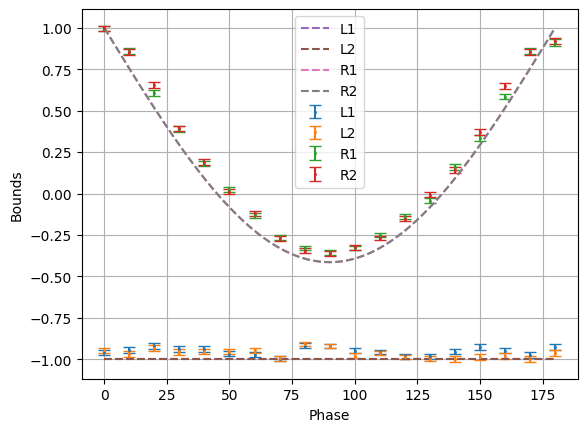

In [24]:
# calculate bounds from averages and errors on the bounds

theta = np.arange(0,181,10)

L1 = np.abs(np.array(avg_exp1x) + np.array(avg_exp1y)) - 1
L2 = np.abs(np.array(avg_exp2x) + np.array(avg_exp2y)) - 1
R1 = 1 - np.abs((np.array(avg_exp1x) - np.array(avg_exp1y)))
R2 = 1 - np.abs((np.array(avg_exp2x) - np.array(avg_exp2y)))

L1_err = np.sqrt(np.array(avg_exp1x_err)**2 + np.array(avg_exp1y_err)**2)
L2_err = np.sqrt(np.array(avg_exp2x_err)**2 + np.array(avg_exp2y_err)**2)
R1_err = np.sqrt(np.array(avg_exp1x_err)**2 + np.array(avg_exp1y_err)**2)
R2_err = np.sqrt(np.array(avg_exp2x_err)**2 + np.array(avg_exp2y_err)**2)

plt.errorbar(theta,L1, L1_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="L1")
plt.errorbar(theta,L2, L2_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="L2")
plt.errorbar(theta,R1, R1_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="R1")
plt.errorbar(theta,R2, R2_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label="R2")
plt.legend(loc="upper left")

plt.plot(delays, L1_thry, '--', label="L1")
plt.plot(delays, L2_thry, '--', label="L2")
plt.plot(delays, R1_thry, '--', label="R1")
plt.plot(delays, R2_thry, '--', label="R2")

plt.ylabel("Bounds")
plt.xlabel("Phase")
plt.legend()
plt.grid()

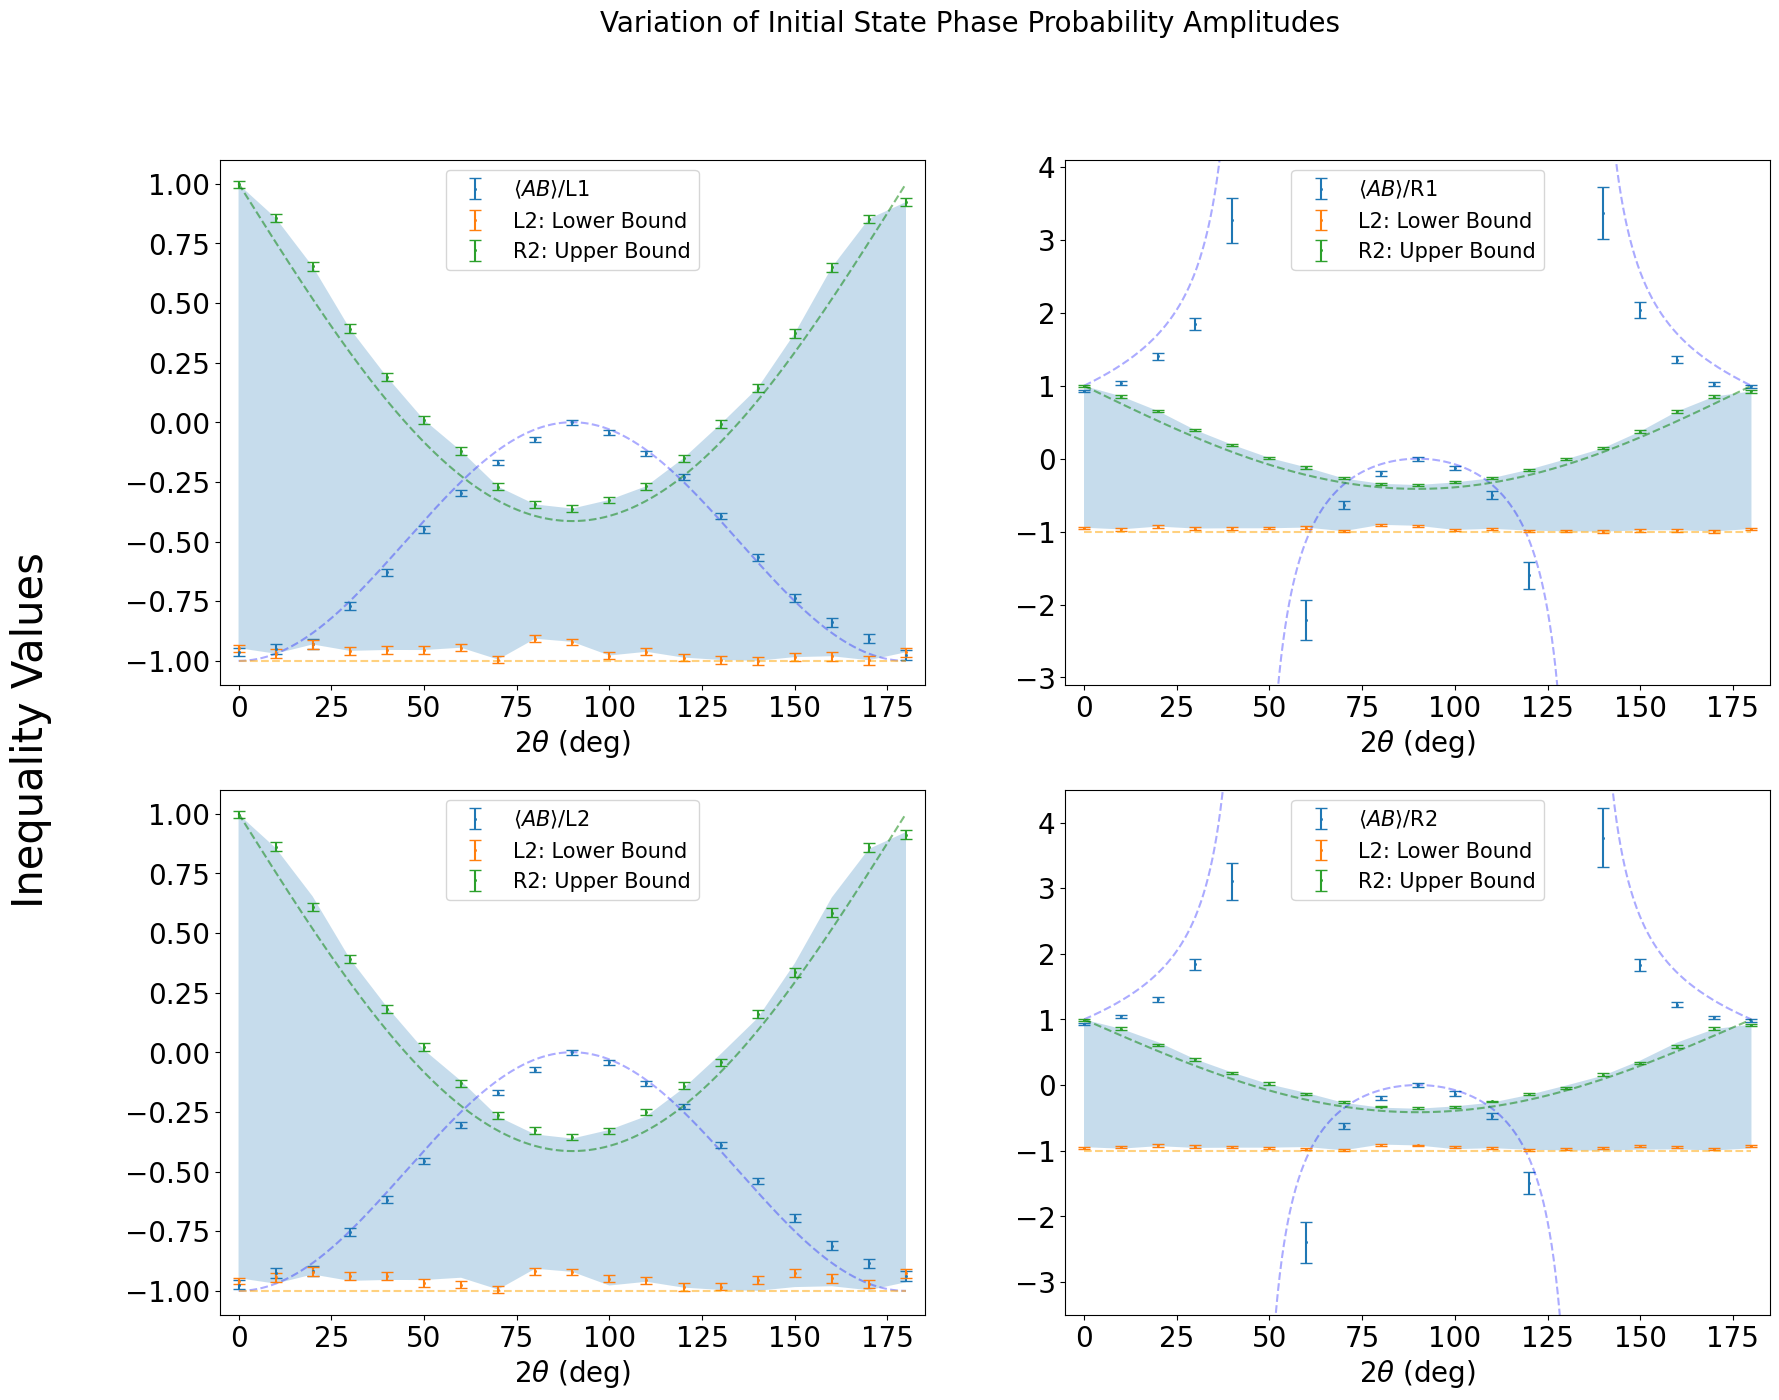

In [25]:
# generating the paper figures

fig, ax = plt.subplots(2, 2, figsize = (20, 15))
fig.suptitle('Variation of Initial State Phase Probability Amplitudes', fontsize=20)
#fig.supxlabel('Initial State Probability Amplitude Angles (deg)', fontsize=20)
fig.supylabel('Inequality Values', fontsize=30)

bounds = [[L1,L1_err,L2,L2_err,R2,R2_err,'L1'], [R1,R1_err,L2,L2_err,R2,R2_err,'R1'], [L2,L2_err,L1,L1_err,R1,R1_err,'L2'], [R2,R2_err,L1,L1_err,R1,R1_err,'R2']]

for nn, ax in enumerate(ax.flat):
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    ineq = np.array(avg_par) / np.array(bounds[nn][0])
    ineq_err = np.abs(np.array(ineq)) * np.sqrt((np.array(avg_err) / np.array(avg_par))**2 + (np.array(bounds[nn][1]) / np.array(bounds[nn][0]))**2)
    if nn in [1,3]:
        ax.errorbar(np.delete(theta,[5,13]),np.delete(ineq,[5,13]), np.delete(ineq_err,[5,13]), linestyle = '', marker='s', capsize = 4, markersize = 1, label= r'$\left\langle AB \right\rangle$/' + bounds[nn][6])
        ax.plot(np.linspace(0,180,1000)[0:250], np.array(parity_sim)[0:250]/np.array(R2_thry)[0:250], '--', color = 'blue', alpha=0.33 , label="")
        ax.plot(np.linspace(0,180,1000)[251:750], np.array(parity_sim)[251:750]/np.array(R2_thry)[251:750], '--', color = 'blue', alpha=0.33 , label="")
        ax.plot(np.linspace(0,180,1000)[751:], np.array(parity_sim)[751:]/np.array(R2_thry)[751:], '--', color = 'blue', alpha=0.33 , label="")
    if nn in [0,2]:
        ax.plot(np.linspace(0,180,1000), np.array(parity_sim)/np.array(L2_thry), '--', color = 'blue', alpha=0.33 , label="")
        ax.errorbar(theta,ineq, ineq_err, linestyle = '', marker='s', capsize = 4, markersize = 1, label= r'$\left\langle AB \right\rangle$/' + bounds[nn][6])
    ax.errorbar(theta,bounds[nn][2], bounds[nn][3], linestyle = '', marker='s', capsize = 4, markersize = 1, label="L2: Lower Bound")
    ax.errorbar(theta,bounds[nn][4], bounds[nn][5], linestyle = '', marker='s', capsize = 4, markersize = 1, label="R2: Upper Bound")
    if nn in [2,3]: 
        ax.plot(delays, L1_thry, '--', color = 'orange', alpha=0.5)
        ax.plot(delays, R1_thry, '--', color = 'green', alpha=0.5)
    if nn in [0,1]: 
        ax.plot(delays, L2_thry, '--', color = 'orange', alpha=0.5)
        ax.plot(delays, R2_thry, '--', color = 'green', alpha=0.5)
    ax.legend(loc="upper center", prop={'size': 15})
    ax.set_ylim([-1.1,1.1])
    if nn == 1: 
        ax.set_ylim([-3.1,4.1])
    if nn == 3: 
        ax.set_ylim([-3.5,4.5])
    ax.set_xlim([-5, 185])
    ax.fill_between(theta,L2,R2, alpha=0.25)
    ax.set_xlabel(r'$2\theta$ (deg)', fontsize=20)

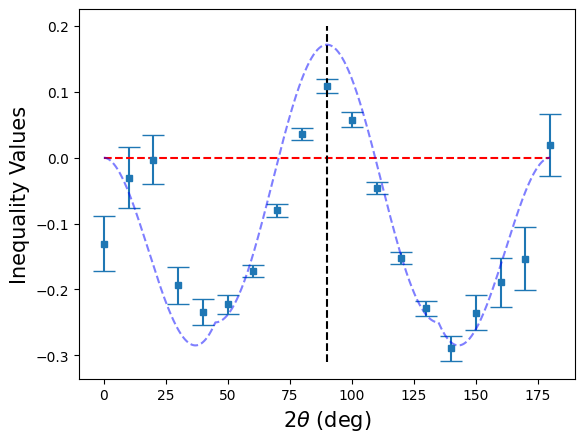

In [26]:
# generating paper figures

eqn_41 = []

for i in range(len(L1_thry)): 
    max_bounds = max([L1_thry[i]*L2_thry[i],L1_thry[i]*R2_thry[i],R1_thry[i]*L2_thry[i],R1_thry[i]*R2_thry[i]])
    min_bounds = min([L1_thry[i]*L2_thry[i],L1_thry[i]*R2_thry[i],R1_thry[i]*L2_thry[i],R1_thry[i]*R2_thry[i]])
    eqn_41.append((parity_sim[i] - max_bounds)*(parity_sim[i] - min_bounds))

    
AB = avg_par
AB_err = avg_err

bound_products = [L1*L2,L1*R2,R1*L2,R1*R2]
bound_products_err = []
bound_products_err.append(np.abs(L1*L2)*np.sqrt(((L2_err) / (L2))**2 + ((L1_err) / (L1))**2))
bound_products_err.append(np.abs(L1*R2)*np.sqrt(((R2_err) / (R2))**2 + ((L1_err) / (L1))**2))
bound_products_err.append(np.abs(R1*L2)*np.sqrt(((L2_err) / (L2))**2 + ((R1_err) / (R1))**2))
bound_products_err.append(np.abs(R1*R2)*np.sqrt(((R2_err) / (R2))**2 + ((R1_err) / (R1))**2))

min_idx = 0
max_idx = 0

x = theta
y = []
z = []


for i in range(len(AB)): 
    bound_products_invd = [bound_products[0][i], bound_products[1][i], bound_products[2][i], bound_products[3][i]]
    bound_products_invd_err = [bound_products_err[0][i], bound_products_err[1][i], bound_products_err[2][i], bound_products_err[3][i]]
    min_idx = bound_products_invd.index(min(bound_products_invd))
    max_idx = bound_products_invd.index(max(bound_products_invd))
    AB_max = AB[i] - bound_products_invd[max_idx]
    AB_min = AB[i] - bound_products_invd[min_idx]
    #print(AB_max*AB_min)
    y.append(AB_max*AB_min)
    
    AB_max_err = np.sqrt(AB_err[i]**2 + bound_products_invd_err[max_idx]**2)
    AB_min_err = np.sqrt(AB_err[i]**2 + bound_products_invd_err[min_idx]**2)
    
    overall_err = np.abs(AB_max*AB_min)*np.sqrt(((AB_max_err) / (AB_max))**2 + ((AB_min_err) / (AB_min))**2)
    #print(overall_err)
    z.append(overall_err)

plt.errorbar(x,y,z, linestyle = '', marker='s', capsize = 8, markersize = 5, label= '')
plt.xlabel(r'2$\theta$ (deg)', fontsize=15)
plt.ylabel('Inequality Values', fontsize=15)
plt.tick_params(axis='both', labelsize = 10)
plt.xlim([-10, 190])
#plt.ylim([-0.008, 0.065])
plt.hlines(0,0,180,linestyle = '--',color = 'r')
plt.vlines(90,-0.31, 0.20,linestyle = '--',color = 'k')
plt.plot(delays,eqn_41,'--', color = 'blue', alpha=0.5)

#print(AB_max*AB_min/err)

# Measuring the optimal initial state

In [27]:
# read txt file and import as dictionary

with open('Optimal Initial State Measurements\\optimal X.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)

(-1.1, 1.1)

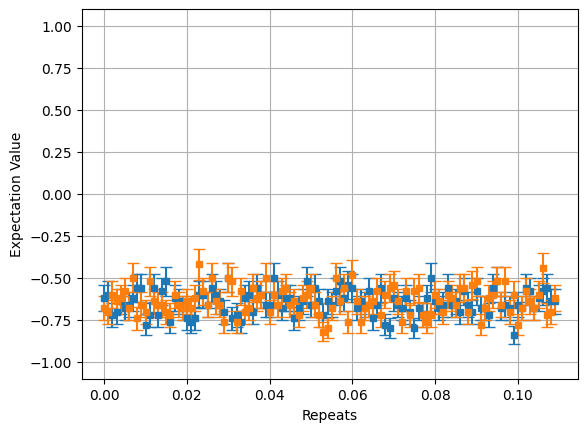

In [28]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

keys = ["Ion 1","Ion 2"]
repeats = []
for i in data.keys():
    if i[0] in repeats:
        continue
    repeats.append(i[0])
avg_ion1x_0 = []
avg_ion1x_err_0 = []
avg_ion2x_0 = []
avg_ion2x_err_0 = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1
    avg_ion1x_0.append(up1_count/n)
    avg_ion2x_0.append(up2_count/n)
    avg_ion1x_err_0.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    avg_ion2x_err_0.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))
    
avg_ion1x_0 = 2*np.array(avg_ion1x_0) - 1
avg_ion1x_err_0 = 2*np.array(avg_ion1x_err_0)
avg_ion2x_0 = 2*np.array(avg_ion2x_0) - 1
avg_ion2x_err_0 = 2*np.array(avg_ion2x_err_0)

plt.errorbar(repeats,avg_ion1x_0,(np.array(avg_ion1x_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.errorbar(repeats,avg_ion2x_0,(np.array(avg_ion2x_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Expectation Value")
plt.ylim([-1.1,1.1])


In [29]:
# read txt file and import as dictionary

with open('Optimal Initial State Measurements\\optimal Y.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)

109


(-1.1, 1.1)

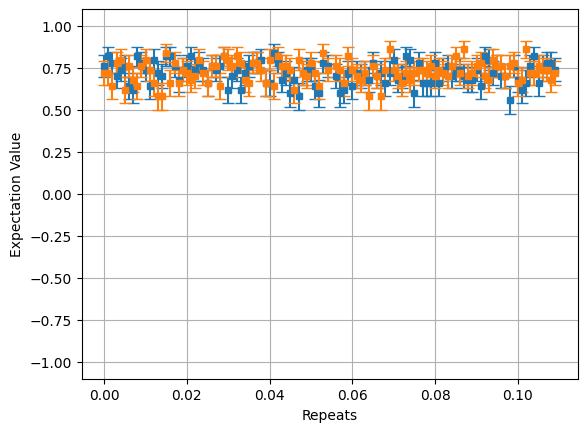

In [30]:
# calculate excited state populations for each ion from dictionary values and calculate expectation values

# removing one erroneous point when ion escaped the trap
del data[(0.05500000000000004, 'Ion 1')]
del data[(0.05500000000000004, 'Ion 2')]


keys = ["Ion 1","Ion 2"]
repeats = []
for i in data.keys():
    if i[0] in repeats:
        continue
    repeats.append(i[0])
avg_ion1y_0 = []
avg_ion1y_err_0 = []
avg_ion2y_0 = []
avg_ion2y_err_0 = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    up1_count = 0
    up2_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] == 1: 
            up1_count += 1
        if ion2[j] == 1: 
            up2_count += 1   
    avg_ion1y_0.append(up1_count/n)
    avg_ion2y_0.append(up2_count/n)
    avg_ion1y_err_0.append(np.sqrt(up1_count/n * (1.0 - up1_count/n) / n))
    avg_ion2y_err_0.append(np.sqrt(up2_count/n * (1.0 - up2_count/n) / n))
    
avg_ion1y_0 = 2*np.array(avg_ion1y_0) - 1
avg_ion1y_err_0 = 2*np.array(avg_ion1y_err_0)
avg_ion2y_0 = 2*np.array(avg_ion2y_0) - 1
avg_ion2y_err_0 = 2*np.array(avg_ion2y_err_0)

print(len(avg_ion1y_0))

plt.errorbar(repeats,avg_ion1y_0,(np.array(avg_ion1y_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.errorbar(repeats,avg_ion2y_0,(np.array(avg_ion2y_err_0)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Expectation Value")
plt.ylim([-1.1,1.1])

In [31]:
# read txt file and import as dictionary

with open('Optimal Initial State Measurements\\optimal AB.txt', 'r') as f:
    s = f.read()
    data = ast.literal_eval(s)

Text(0, 0.5, 'Parity')

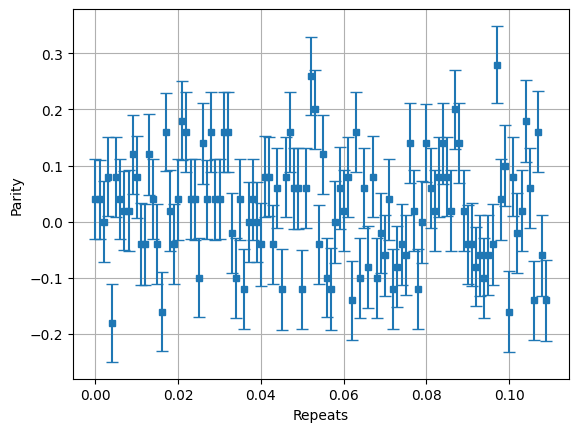

In [32]:
# calculate populations of states 00, 10, 01, 11 from dictionary values and calculate parity

keys = ["Ion 1","Ion 2"]
repeats = []
for i in data.keys():
    if i[0] in repeats:
        continue
    repeats.append(i[0])
parity_opt = []
err_parity_opt = []
for i in repeats: 
    ion1 = data[(i,keys[0])]
    ion2 = data[(i,keys[1])]
    upup_count = 0
    downdown_count = 0
    others_count = 0
    n = len(ion1)
    for j in range(n): 
        if ion1[j] != ion2[j]: 
            others_count += 1
        elif ion1[j] == 0: 
            downdown_count += 1
        else: 
            upup_count += 1
    parity_opt.append(upup_count/n + downdown_count/n - others_count/n)
    upup_err = np.sqrt(upup_count/n * (1.0 - upup_count/n) / n)
    downdown_err = np.sqrt(downdown_count/n * (1.0 - downdown_count/n) / n)
    others_err = np.sqrt(others_count/n * (1.0 - others_count/n) / n)
    err = np.sqrt(upup_err**2 + downdown_err**2 + others_err**2)
    err_parity_opt.append(err)

plt.errorbar(repeats,parity_opt,(np.array(err_parity_opt)), linestyle = '', marker='s', capsize = 4, markersize = 5)
plt.grid()
plt.xlabel("Repeats")
plt.ylabel("Parity")


Text(0, 0.5, 'Measured Value')

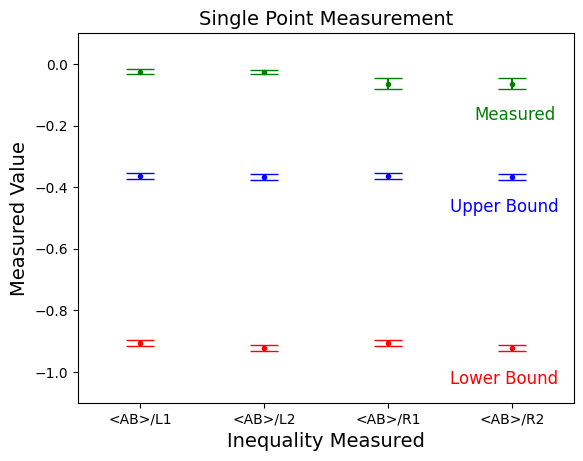

In [33]:
# generating figure which corresponds to tabular values in the paper (see Table I)

parity_opt = np.average(parity_opt)

L1 = np.abs(np.average(avg_ion1x_0) + np.average(avg_ion1y_0)) - 1
L2 = np.abs(np.average(avg_ion2x_0) + np.average(avg_ion2y_0)) - 1
R1 = 1 - np.abs((np.average(avg_ion1x_0) - np.average(avg_ion1y_0)))
R2 = 1 - np.abs((np.average(avg_ion2x_0) - np.average(avg_ion2y_0)))

avg_ion1x_err_0 = np.sqrt(np.sum(np.array(avg_ion1x_err_0)**2))/len(np.array(avg_ion1x_err_0))
avg_ion1y_err_0 = np.sqrt(np.sum(np.array(avg_ion1y_err_0)**2))/len(np.array(avg_ion1y_err_0))
avg_ion2x_err_0 = np.sqrt(np.sum(np.array(avg_ion2x_err_0)**2))/len(np.array(avg_ion2x_err_0))
avg_ion2y_err_0 = np.sqrt(np.sum(np.array(avg_ion2y_err_0)**2))/len(np.array(avg_ion2y_err_0))
err_parity_opt = np.sqrt(np.sum(np.array(err_parity_opt)**2))/len(np.array(err_parity_opt))

L1_err = np.sqrt(np.average(avg_ion1x_err_0)**2 + np.average(avg_ion1y_err_0)**2)
L2_err = np.sqrt(np.average(avg_ion2x_err_0)**2 + np.average(avg_ion2y_err_0)**2)
R1_err = np.sqrt(np.average(avg_ion1x_err_0)**2 + np.average(avg_ion1y_err_0)**2)
R2_err = np.sqrt(np.average(avg_ion2x_err_0)**2 + np.average(avg_ion2y_err_0)**2)

AB_L1_err = np.abs((parity_opt/L1)) * np.sqrt(((err_parity_opt) / (parity_opt))**2 + ((L1_err) / (L1))**2)
AB_L2_err = np.abs((parity_opt/L2)) * np.sqrt(((err_parity_opt) / (parity_opt))**2 + ((L2_err) / (L2))**2)
AB_R1_err = np.abs((parity_opt/R1)) * np.sqrt(((err_parity_opt) / (parity_opt))**2 + ((R1_err) / (R1))**2)
AB_R2_err = np.abs((parity_opt/R2)) * np.sqrt(((err_parity_opt) / (parity_opt))**2 + ((R2_err) / (R2))**2)

xlabels = ['<AB>/L1','<AB>/L2','<AB>/R1','<AB>/R2']
upper_bounds = [R2,R1,R2,R1]
upper_bounds_err = [R2_err,R1_err,R2_err,R1_err]
lower_bounds = [L2,L1,L2,L1]
lower_bounds_err = [L2_err,L1_err,L2_err,L1_err]
AB = [parity_opt/L1,parity_opt/L2,parity_opt/R1,parity_opt/R2]
AB_err = [AB_L1_err,AB_L2_err,AB_R1_err,AB_R2_err]

plt.xlim([-0.50,3.50])
plt.ylim([-1.1,0.1])

plt.errorbar(xlabels,AB, AB_err, color = 'g', linestyle = '', marker='o', capsize = 10, markersize = 3)
plt.errorbar(xlabels,upper_bounds, upper_bounds_err, color = 'b', linestyle = '', marker='o', capsize = 10, markersize = 3)
plt.errorbar(xlabels,lower_bounds, lower_bounds_err, color = 'r', linestyle = '', marker='o', capsize = 10, markersize = 3)
plt.text(2.7, -0.18, 'Measured', fontsize=12, color='g')
plt.text(2.5, -0.48, 'Upper Bound', fontsize=12, color='b')
plt.text(2.5, -1.04, 'Lower Bound', fontsize=12, color='r')

plt.title("Single Point Measurement", fontsize = 14)
plt.xlabel("Inequality Measured", fontsize = 14)
plt.ylabel("Measured Value", fontsize = 14)